# Correlation between FGW distance and MACE-relaxed energy

This notebook compares the relative FGW distances ($\Delta d_{\mathrm{FGW}}$) with the relative MACE-relaxed energies ($\Delta E_{\mathrm{MACE-relaxed}}$) for

- KI/NaCl
- GaP/GaAs
- GaN/$\mathrm{Al_{2}O_3}$


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from matplotlib.ticker import FormatStrFormatter

# Input files
systems = ["KI_NaCl", "GaP_GaAs", "GaN_Al2O3"]
titles = ["KI/NaCl", "GaP/GaAs", r"GaN/$\mathrm{Al_{2}O_{3}}$"]
mace_paths = [f"mace_results/{system}.csv" for system in systems]
# Column names
mace_energy_col = "mace_relaxed_energy"
fgw_col = "fgw_distance_megn_050"
# Figure layout
fig_width = 7.2
fig_height = 3.2
fig_layout = dict(
    left=0.05,
    right=0.95,
    bottom=0.05,
    top=0.95,
    wspace=0.25,
)
# Plotting configuration
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
})
# Hexbin and histogram style
scatter_cmap = "Blues"
hex_gridsize = 12
hist_color = "#D3D8DC"
hist_edge = "#000000"
hist_bins = 24
hist_ratio = 0.18
# Scatter and fitting style
point_color = "#3F6C88"
point_size = 18
ci_color = "#D3D3D3"
fit_color = "#000000"


## Data processing and correlation analysis

In [38]:
mace_data = []

for system, title, mace_path in zip(systems, titles, mace_paths):
    df = pd.read_csv(mace_path).copy()
    # Convert absolute values to relative values for better visualization.
    df["relative_distance"] = df[fgw_col] - df[fgw_col].min()
    df["relative_energy"] = df[mace_energy_col] - df[mace_energy_col].min()
    x = df["relative_distance"].to_numpy(dtype=float)
    y = df["relative_energy"].to_numpy(dtype=float)
    r = float(pearsonr(x, y).statistic)
    rho = float(spearmanr(x, y).statistic)
    mace_data.append((title, x, y, r, rho))


## Plot correlations


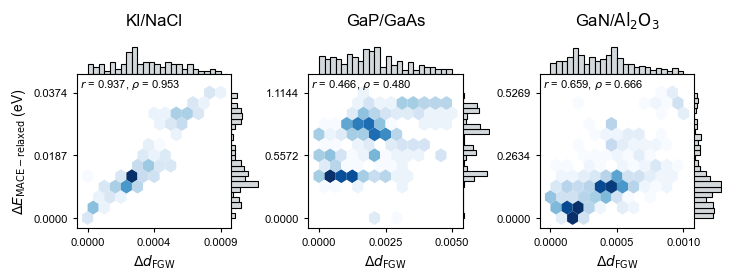

In [39]:
fig = plt.figure(figsize=(fig_width, fig_height))
outer = fig.add_gridspec(
    1, 3,
    left=fig_layout["left"],
    right=fig_layout["right"],
    bottom=fig_layout["bottom"],
    top=fig_layout["top"],
    wspace=fig_layout["wspace"],
)

# Hexbin with marginal histograms
for col_idx in range(3):
    title, x, y, r, rho = mace_data[col_idx]
    inner = outer[0, col_idx].subgridspec(2, 2, height_ratios=[1.0, 5.0], width_ratios=[5.0, 1.0], hspace=0.0, wspace=0.0)
    # Add axes
    ax_histx = fig.add_subplot(inner[0, 0])
    ax = fig.add_subplot(inner[1, 0], sharex=ax_histx)
    ax_histy = fig.add_subplot(inner[1, 1], sharey=ax)
    # Draw main hexbin plot
    ax.set_box_aspect(1)
    ax.hexbin(x, y, gridsize=hex_gridsize, cmap=scatter_cmap, mincnt=1, linewidths=0)
    corr_label = rf"$r$ = {r:.3f}, $\rho$ = {rho:.3f}"
    ax.text(0.02, 0.98, corr_label, transform=ax.transAxes, ha="left", va="top")
    ax.tick_params(direction="out", length=3, width=0.8, top=False, right=False)
    ax.set_xticks(np.linspace(x.min(), x.max(), 3))
    ax.set_yticks(np.linspace(y.min(), y.max(), 3))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.4f"))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.4f"))
    ax.set_ylim(y.min()-0.08*(y.max()-y.min()), y.max()+0.15*(y.max()-y.min()))
    ax.set_xlim(x.min()-0.08*(x.max()-x.min()), x.max()+0.08*(x.max()-x.min()))
    ax.set_xlabel(r"$\Delta d_{\mathrm{FGW}}$")
    if col_idx == 0:
        ax.set_ylabel(r"$\Delta E_{\mathrm{MACE-relaxed}}$ (eV)")
    # Draw marginal histograms
    ax_histx.hist(x, bins=hist_bins, color=hist_color, edgecolor=hist_edge, linewidth=0.8)
    ax_histx.axis("off")
    ax_histy.hist(y, bins=hist_bins, orientation="horizontal", color=hist_color, edgecolor=hist_edge, linewidth=0.8)
    ax_histy.axis("off")
    # Add the panel title
    ax_histx.set_title(title, pad=15)
    fig.canvas.draw()
    ax_pos = ax.get_position()
    ax_histx.set_position((ax_pos.x0, ax_pos.y1, ax_pos.width, ax_pos.height*hist_ratio))
    ax_histy.set_position((ax_pos.x1, ax_pos.y0, ax_pos.width*hist_ratio, ax_pos.height))

# Output files
plt.savefig("fgw_mace_relaxed_correlation.pdf", dpi=300, bbox_inches="tight")
plt.show()
